In [2]:
import snowflake.connector
from sqlalchemy import create_engine
from sqlalchemy import text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from scipy.stats import zscore
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from catboost import CatBoostClassifier
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LassoCV
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta

from snowflake.connector.pandas_tools import write_pandas

In [3]:
pd.set_option('display.max_columns', None)

In [57]:
url = URL(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
)
engine = create_engine(url)
connection = engine.connect()

In [143]:
query_stopgo = '''
select 
ping_id,
jluvr,
request_datetime,
partner_name,
raw_request_json,
raw_response_json,
accepted,
response_type,
CASE 
    WHEN ROW_NUMBER() OVER(PARTITION BY jluvr ORDER BY request_datetime ASC) > 1 THEN 1 
    ELSE 0 
END AS is_dup_ping
from DBT_PROD.ANALYTICS.FCT_PING_PARTNER_TRANSACTION
where partner_name = 'stopGoNetwork'
'''

In [284]:
query_trio = '''
select 
ping_id,
jluvr,
request_datetime,
partner_name,
raw_request_json,
raw_response_json,
accepted,
response_type,
CASE 
    WHEN ROW_NUMBER() OVER(PARTITION BY jluvr ORDER BY request_datetime ASC) > 1 THEN 1 
    ELSE 0 
END AS is_dup_ping
from DBT_PROD.ANALYTICS.FCT_PING_PARTNER_TRANSACTION
where partner_name = 'Trio' and (request_date < '2025-08-01' or request_date > '2025-10-20')
'''

In [286]:
with engine.connect() as con:
    con.execute(text("use database dbt_prod"))
    con.execute(text("use schema ANALYTICS"))
    df_stopgo = pd.read_sql(query_stopgo, con)
    df_trio = pd.read_sql(query_trio, con)

In [287]:
len(df_stopgo)

30502

In [288]:
len(df_trio)

3721

In [456]:
len(df_trio.jluvr.unique())

2303

# Trio

In [290]:
import pandas as pd
import json
import re

def camel_to_snake(name):
    """Converts camelCase to snake_case."""
    name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', name).lower()

def process_json_row(json_string):
    """Parses a JSON string and yields a list of flattened dictionaries."""
    try:
        # Parse the string into a dictionary (skip if it's somehow already a dict)
        json_data = json.loads(json_string) if isinstance(json_string, str) else json_string
    except (TypeError, json.JSONDecodeError, ValueError):
        # Return an empty dict if the row is null or invalid JSON
        return [{}]

    # Extract the main blocks to ignore their root names
    lease_app = json_data.get("leaseApplication", {})
    applicants = lease_app.get("applicants", [{}])
    property_data = lease_app.get("property", {})
    expenses_data = lease_app.get("expenses", {})
    
    flat_records = []
    
    # Process each applicant (in case there are co-applicants in the list)
    for applicant in applicants:
        flat_record = {}
        
        def flatten(x, prefix=''):
            if isinstance(x, dict):
                for key, val in x.items():
                    snake_key = camel_to_snake(key)
                    flatten(val, prefix + snake_key + '_')
            elif isinstance(x, list):
                for item in x:
                    flatten(item, prefix)
            else:
                final_value = x.lower() if isinstance(x, str) else x
                column_name = prefix[:-1] # Remove the trailing underscore
                if column_name:
                    flat_record[column_name] = final_value

        # Flatten components
        flatten(applicant)
        flatten(property_data)
        flatten(expenses_data)
        
        if flat_record:
            flat_records.append(flat_record)
            
    return flat_records if flat_records else [{}]

# --- Applying to your DataFrame ---

# 1. Apply the function to parse the JSON and create a list of dictionaries per row
df_trio['flattened_data'] = df_trio['raw_request_json'].apply(process_json_row)

# 2. Explode the list so if there are multiple applicants in one JSON, they get their own rows
df_trio = df_trio.explode('flattened_data')

# 3. Fast expansion: Convert the column of dictionaries into a new DataFrame
# We keep the original index so it aligns perfectly with your existing df_trio data
expanded_df = pd.DataFrame(df_trio['flattened_data'].tolist(), index=df_trio.index)

# 4. Join the new columns back to the original DataFrame
df_trio_expanded = pd.concat([df_trio.drop(columns=['flattened_data', 'raw_request_json']), expanded_df], axis=1)


In [292]:
# 1. Ensure request_datetime is a true datetime object and sort the data chronologically
df_trio_expanded['request_datetime'] = pd.to_datetime(df_trio_expanded['request_datetime'])
df_trio_expanded = df_trio_expanded.sort_values('request_datetime')

# 2. Time-based rolling windows require a datetime index
df_indexed = df_trio_expanded.set_index('request_datetime')

# 3. Calculate the rolling means (closed='left' guarantees we only look BEFORE the current row)
# '3D' = 3 Days, '7D' = 7 Days
df_trio_expanded['rolling_3d_accept_rate'] = df_indexed['accepted'].rolling('3D', closed='left').mean().values
df_trio_expanded['rolling_7d_accept_rate'] = df_indexed['accepted'].rolling('7D', closed='left').mean().values

# 4. Fill any NaNs created at the very beginning of the dataset (where there is no history)
df_trio_expanded[['rolling_3d_accept_rate', 'rolling_7d_accept_rate']] = df_trio_expanded[['rolling_3d_accept_rate', 'rolling_7d_accept_rate']].fillna(-1)


In [296]:
trio_columns_to_keep = ['accepted','request_datetime', 'is_dup_ping','addresses_address_type', 'addresses_years_at_address','employments_retired_ind',
       'employments_disabled_ind', 'declarations_party_to_lawsuit',
       'declarations_delinquent_on_fed_debt', 'declarations_obligated_alimony',
       'declarations_down_payment_borrowed', 'declarations_endorser_on_note',
       'declarations_permanent_resident_alien',
       'declarations_intend_primary_occupancy',
       'declarations_interest_in_property_last3_years',
       'assets_real_estate_owned_amount', 'assets_retirement_fund',
       'purchase_price','marrital_status', 'addresses_ownership_type',
        'employments_monthly_income', 'income_base',
       'assets_amount', 'ethnicity', 'race_types','state','rent','rolling_3d_accept_rate', 'rolling_7d_accept_rate']

In [299]:
df_trio_final = df_trio_expanded[trio_columns_to_keep]

In [302]:
df_trio_final.dtypes

accepted                                                  int64
request_datetime                                 datetime64[ns]
is_dup_ping                                               int64
addresses_address_type                                   object
addresses_years_at_address                              float64
employments_retired_ind                                  object
employments_disabled_ind                                 object
declarations_party_to_lawsuit                            object
declarations_delinquent_on_fed_debt                      object
declarations_obligated_alimony                           object
declarations_down_payment_borrowed                       object
declarations_endorser_on_note                            object
declarations_permanent_resident_alien                    object
declarations_intend_primary_occupancy                    object
declarations_interest_in_property_last3_years            object
assets_real_estate_owned_amount         

In [304]:
import pandas as pd

# 1. Drop rows where 'accepted' is null
df_trio_final = df_trio_final.dropna(subset=['accepted'])

# 2. Find boolean columns dynamically
bool_cols = [
    col for col in df_trio_final.columns 
    if df_trio_final[col].apply(lambda x: isinstance(x, bool)).any()
]

# 3. FIX: Replace True/False, fill the NaNs with -1, THEN cast to int64
df_trio_final[bool_cols] = df_trio_final[bool_cols].replace({
    True: 1, 
    False: 0, 
}).fillna(-1).astype('int64')

# 4. Separate your remaining columns by their data type
numeric_cols = df_trio_final.select_dtypes(include=['number']).columns
object_cols = df_trio_final.select_dtypes(include=['object']).columns

# 5. Fill remaining nulls with the appropriate data type
df_trio_final[numeric_cols] = df_trio_final[numeric_cols].fillna(-1)
df_trio_final[object_cols] = df_trio_final[object_cols].fillna("-1")

In [306]:
df_trio_final.columns

Index(['accepted', 'request_datetime', 'is_dup_ping', 'addresses_address_type',
       'addresses_years_at_address', 'employments_retired_ind',
       'employments_disabled_ind', 'declarations_party_to_lawsuit',
       'declarations_delinquent_on_fed_debt', 'declarations_obligated_alimony',
       'declarations_down_payment_borrowed', 'declarations_endorser_on_note',
       'declarations_permanent_resident_alien',
       'declarations_intend_primary_occupancy',
       'declarations_interest_in_property_last3_years',
       'assets_real_estate_owned_amount', 'assets_retirement_fund',
       'purchase_price', 'marrital_status', 'addresses_ownership_type',
       'employments_monthly_income', 'income_base', 'assets_amount',
       'ethnicity', 'race_types', 'state', 'rent', 'rolling_3d_accept_rate',
       'rolling_7d_accept_rate'],
      dtype='object')

In [328]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool

# 1. Sort chronologically first!
df_trio_final = df_trio_final.sort_values('request_datetime').reset_index(drop=True)

# --- THE THREE-WAY SPLIT ---

# Step A: Carve off the MOST RECENT 10% of data for our final reality check
holdout_idx = int(len(df_trio_final) * 0.90)

historical_df = df_trio_final.iloc[:holdout_idx].copy()
recent_holdout_df = df_trio_final.iloc[holdout_idx:].copy()

# Step B: Standard Random Split on the remaining 90% (80/20 train/validation split)
train_df, val_df = train_test_split(
    historical_df, 
    test_size=0.20, 
    random_state=42, 
    stratify=historical_df['accepted'] 
)

print(f"Train Set (Randomized): {len(train_df)} rows")
print(f"Validation Set (Randomized): {len(val_df)} rows")
print(f"Recent Holdout Set (Chronological): {len(recent_holdout_df)} rows")
print("-" * 40)

# --- CALCULATE RECENCY WEIGHTS ---
# 1. Find the anchor date (the most recent date in the historical training data)
anchor_date = historical_df['request_datetime'].max()

# 2. Set the half-life (21 days means data from 3 weeks ago has 50% importance)
# You can tweak this number! A smaller number makes the model forget the past faster.
half_life_days = 90 
decay_rate = np.log(2) / half_life_days

# 3. Calculate how many days old each row is
train_days_old = np.maximum((anchor_date - train_df['request_datetime']).dt.total_seconds() / (24 * 3600), 0)
val_days_old = np.maximum((anchor_date - val_df['request_datetime']).dt.total_seconds() / (24 * 3600), 0)

# 4. Generate the exponential decay weights
train_weights = np.exp(-decay_rate * train_days_old)
val_weights = np.exp(-decay_rate * val_days_old)

print(f"Weight of newest training row: {train_weights.max():.2f}")
print(f"Weight of oldest training row: {train_weights.min():.2f}")
print("-" * 40)

# --- SETUP FEATURES & TARGETS -----
cols_to_drop = [
    'accepted', 
    'request_datetime'
]

X_train, y_train = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns]), train_df['accepted']
X_val, y_val = val_df.drop(columns=[c for c in cols_to_drop if c in val_df.columns]), val_df['accepted']
X_holdout, y_holdout = recent_holdout_df.drop(columns=[c for c in cols_to_drop if c in recent_holdout_df.columns]), recent_holdout_df['accepted']

# --- CATEGORICAL HANDLING ---
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

for col in cat_cols:
    X_train[col] = X_train[col].fillna('unknown').astype(str).str.strip()
    X_val[col] = X_val[col].fillna('unknown').astype(str).str.strip()
    X_holdout[col] = X_holdout[col].fillna('unknown').astype(str).str.strip()

# --- SCALE POS WEIGHT ---
positive_count = y_train.sum()
negative_count = len(y_train) - positive_count
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1

# --- CREATE POOLS (WITH RECENCY WEIGHTS) ---
# Notice we pass the weight arrays in here!
train_pool = Pool(X_train, y_train, cat_features=cat_cols, weight=train_weights)
val_pool = Pool(X_val, y_val, cat_features=cat_cols, weight=val_weights)

# The holdout pool gets NO weights, because we want to evaluate the raw truth.
holdout_pool = Pool(X_holdout, y_holdout, cat_features=cat_cols) 

# -------- TRAIN THE MODEL ------
params = {
    'iterations': 1000,
    'learning_rate': 0.02,
    'depth': 3,              
    'l2_leaf_reg': 10,        
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'scale_pos_weight': scale_pos_weight,
    'verbose': 0
}

model = CatBoostClassifier(**params)

print("\nTraining on time-weighted randomized historical data...")
model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=100,
    verbose=100
)

# --- THE FINAL REALITY CHECK ---
print("\n" + "=" * 40)
print("TESTING ON OUT-OF-TIME HOLDOUT (MOST RECENT DATA)")
print("=" * 40)

# Predict probabilities on the withheld future data
holdout_preds = model.predict_proba(X_holdout)[:, 1]

# Calculate true AUC
holdout_auc = roc_auc_score(y_holdout, holdout_preds)
print(f"Holdout AUC Score: {holdout_auc:.4f}")  

Train Set (Randomized): 2678 rows
Validation Set (Randomized): 670 rows
Recent Holdout Set (Chronological): 373 rows
----------------------------------------
Weight of newest training row: 1.00
Weight of oldest training row: 0.08
----------------------------------------

Training on time-weighted randomized historical data...
0:	test: 0.5988604	best: 0.5988604 (0)	total: 2.14ms	remaining: 2.14s
100:	test: 0.6242477	best: 0.6245541 (92)	total: 158ms	remaining: 1.41s
200:	test: 0.6317658	best: 0.6317658 (200)	total: 311ms	remaining: 1.24s
300:	test: 0.6345856	best: 0.6347387 (294)	total: 464ms	remaining: 1.08s
400:	test: 0.6398829	best: 0.6407387 (380)	total: 619ms	remaining: 924ms
500:	test: 0.6419099	best: 0.6420541 (496)	total: 775ms	remaining: 772ms
600:	test: 0.6478108	best: 0.6478108 (600)	total: 1.01s	remaining: 669ms
700:	test: 0.6512883	best: 0.6514955 (699)	total: 1.18s	remaining: 501ms
800:	test: 0.6539099	best: 0.6539279 (799)	total: 1.33s	remaining: 331ms
900:	test: 0.656054

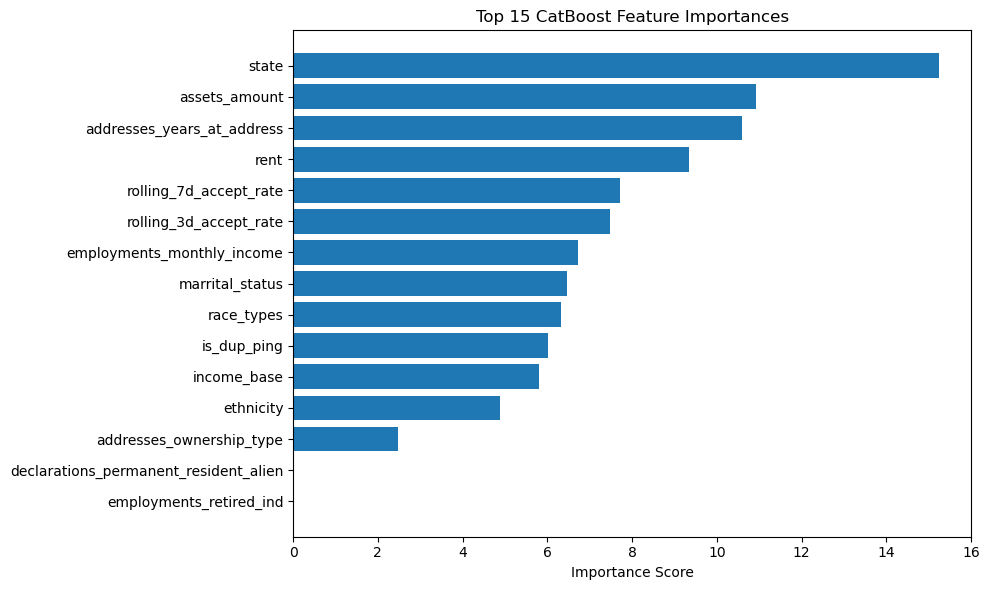

                       Feature  Importance
23                       state   15.242503
20               assets_amount   10.920111
2   addresses_years_at_address   10.584367
24                        rent    9.350251
26      rolling_7d_accept_rate    7.723807
25      rolling_3d_accept_rate    7.486143
18  employments_monthly_income    6.731642
16             marrital_status    6.473583
22                  race_types    6.314179
0                  is_dup_ping    6.004952


In [330]:
import matplotlib.pyplot as plt

# Get feature importances from the trained model
feature_importances = model.get_feature_importance(train_pool)
feature_names = X_train.columns

# Create a DataFrame and sort it 
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6)) 
plt.barh(importance_df['Feature'][:15][::-1], importance_df['Importance'][:15][::-1])
plt.title('Top 15 CatBoost Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df.head(10))

In [332]:
import pandas as pd
import numpy as np

# Let's look at the top 3 categorical drivers and top 2 numeric drivers
top_cats = ['state', 'addresses_ownership_type', 'marrital_status']
top_nums = ['assets_amount', 'rent']
 
print("=== NUMERIC FEATURE DRIFT (Averages) ===")
for col in top_nums:
    hist_avg = historical_df[col].replace(-1, np.nan).mean() # Ignore our -1 fill for accurate math
    hold_avg = recent_holdout_df[col].replace(-1, np.nan).mean()
    diff = ((hold_avg - hist_avg) / hist_avg) * 100
    print(f"{col}:")
    print(f"  Historical Avg: {hist_avg:,.2f}")
    print(f"  Recent Avg:     {hold_avg:,.2f} ({diff:+.1f}% shift)")
    print("-" * 30)

print("\n=== CATEGORICAL DRIFT (Acceptance Rates) ===") 
# We will look at how the acceptance rate changed for the most common categories 
for col in top_cats:
    print(f"Feature: {col}")
    
    # Get the top 3 most common values for this feature in the historical data
    top_3_vals = historical_df[col].value_counts().head(3).index
    
    for val in top_3_vals:
        # Calculate historical acceptance rate for this specific category
        hist_mask = historical_df[col] == val
        hist_rate = historical_df[hist_mask]['accepted'].mean() * 100 if hist_mask.sum() > 0 else 0
        
        # Calculate recent holdout acceptance rate for this specific category
        hold_mask = recent_holdout_df[col] == val
        hold_rate = recent_holdout_df[hold_mask]['accepted'].mean() * 100 if hold_mask.sum() > 0 else 0
        
        print(f"  Value: '{val}'")
        print(f"    Historical Accept Rate: {hist_rate:.1f}%")
        print(f"    Recent Accept Rate:     {hold_rate:.1f}%")
    print("-" * 30) 

=== NUMERIC FEATURE DRIFT (Averages) ===
assets_amount:
  Historical Avg: 170,884.01
  Recent Avg:     108,029.97 (-36.8% shift)
------------------------------
rent:
  Historical Avg: 1,591.25
  Recent Avg:     1,713.80 (+7.7% shift)
------------------------------

=== CATEGORICAL DRIFT (Acceptance Rates) ===
Feature: state
  Value: 'ca'
    Historical Accept Rate: 39.8%
    Recent Accept Rate:     22.5%
  Value: 'tx'
    Historical Accept Rate: 50.7%
    Recent Accept Rate:     48.6%
  Value: 'fl'
    Historical Accept Rate: 45.9%
    Recent Accept Rate:     50.0%
------------------------------
Feature: addresses_ownership_type
  Value: 'rent'
    Historical Accept Rate: 48.4%
    Recent Accept Rate:     46.0%
  Value: 'own'
    Historical Accept Rate: 44.5%
    Recent Accept Rate:     50.6%
  Value: '-1'
    Historical Accept Rate: 5.9%
    Recent Accept Rate:     0.0%
------------------------------
Feature: marrital_status
  Value: 'married'
    Historical Accept Rate: 48.3%
    Rec

# StopGo

In [341]:
df_stopgo.raw_request_json[0]

'{"income":"4000","lastName":"Valbuena","driverState":"TX","purpose":"other","postalCode":"77094","jobTitle":"Selector","bankName":"Chase","bankruptcy":"N","mailing":"Y","directDeposit":"N","frequency":"weekly","driverLicense":"870356903","company":"Capstone","military":"N","accountLength":"10","email":"diegoevg11@gmail.com","timeJob":"12","aff":"NIC001XP","amount":"900","creditScore":"poor","payDateNext":"2025-10-31","homePhone":"3465795795","accountType":"checking","locality":"Katy","ipAddress":"174.203.4.202","userAgent":"Safari 604 - mobile","accountNumber":"691812260","timeAddress":"12","accountABA":"111000614","SSN":"iEy6zYgYGPfopy51FMdW5A==","firstName":"Diego","apiToken":"1cc292a5-2626-45dc-88be-2cb062c6fe2b","termsAgreed":"Y","mobilePhone":"3465795795","streetAddress":"21077 Kingsland Boulevard","homeOwner":"rent","dob":"1994-03-11","domain":"https://www.cashcenter.ai/?adid=CCAI98200202&phone=3465795795&custemail=diegoevg11%40gmail.com&custzip=77450&XID=YSAM482100TR1164&utm_me

In [353]:
import pandas as pd
import json

# Replace 'raw_request_json' if your column has a different name
json_column_name = 'raw_request_json'

def parse_json_safely(val):
    """Safely converts JSON strings to dictionaries, returning {} for bad/null data."""
    try:
        # If it's already a dictionary, just return it. Otherwise, parse the string.
        return json.loads(val) if isinstance(val, str) else (val or {})
    except (json.JSONDecodeError, TypeError):
        return {}

# 1. Parse the JSON strings into a Pandas Series of dictionaries
parsed_series = df_stopgo['raw_request_json'].apply(parse_json_safely)

# 2. Expand those dictionaries into a brand new DataFrame.
# CRITICAL: We explicitly pass the original DataFrame's index to guarantee rows don't shuffle.
parsed_df = pd.DataFrame(parsed_series.tolist(), index=df_stopgo_expanded.index)

# 3. Concatenate (join) the new parsed columns to the original DataFrame
df_stopgo_expanded = pd.concat([df_stopgo, parsed_df], axis=1)

# 4. (Optional) Drop the original raw JSON column to save memory
df_stopgo_expanded = df_stopgo_expanded.drop(columns=[json_column_name])


In [437]:
import pandas as pd
import numpy as np

def flag_invalid_leads(df):
    """
    Evaluates a dataframe against all data quality rules. Appends:
    1. 'is_invalid_leads' (1 = invalid, 0 = valid)
    2. 'invalid_reasons' (A pipe-separated list of broken rules)
    """
    # Start by assuming all rows are valid and have no errors
    is_invalid = pd.Series(False, index=df.index)
    reasons = pd.Series("", index=df.index)

    def mark_invalid(condition, error_message):
        """Helper to flip the invalid flag AND record the specific error message."""
        nonlocal is_invalid, reasons
        
        # Ensure condition has no NaNs
        clean_condition = condition.fillna(False)
        
        # Flip the binary flag
        is_invalid = is_invalid | clean_condition
        
        # Append the error message (with a separator) to the failing rows
        reasons[clean_condition] = reasons[clean_condition] + error_message + " | "

    # ---------------------------------------------------------
    # 1. "CANNOT BE EMPTY" CHECKS
    # ---------------------------------------------------------
    must_not_be_empty = [
        'accountABA', 'accountLength', 'accountNumber', 'accountType', 'amount', 
        'bankName', 'company', 'dob', 'domain', 'driverLicense', 'driverState', 
        'email', 'firstName', 'homePhone', 'income', 'ipAddress', 'jobTitle', 
        'lastName', 'locality', 'payDate', 'postalCode', 'region', 'SSN', 
        'streetAddress', 'timeAddress', 'userAgent', 'workPhone'
    ]
    for col in must_not_be_empty:
        if col in df.columns:
            is_empty = df[col].isna() | (df[col].astype(str).str.strip().isin(['', 'nan', 'None']))
            mark_invalid(is_empty, f"{col}: Cannot be empty")

    # ---------------------------------------------------------
    # 2. NUMERIC CHECKS (> 0)
    # ---------------------------------------------------------
    numeric_greater_zero = ['accountLength', 'amount', 'income', 'timeAddress']
    for col in numeric_greater_zero:
        if col in df.columns:
            num_val = pd.to_numeric(df[col], errors='coerce')
            has_data = df[col].notna() & (df[col].astype(str).str.strip() != '')
            
            mark_invalid((num_val <= 0) & has_data, f"{col}: Must be > 0")
            mark_invalid(num_val.isna() & has_data, f"{col}: Invalid numeric value")

    # ---------------------------------------------------------
    # 3. LENGTH & FORMAT CHECKS
    # ---------------------------------------------------------
    def valid_data(col):
        return df[col].notna() & (df[col].astype(str).str.strip() != '') & (df[col].astype(str) != 'nan')

    if 'accountNumber' in df.columns:
        str_len = df['accountNumber'].astype(str).str.strip().str.len()
        mark_invalid(~str_len.between(4, 30) & valid_data('accountNumber'), "accountNumber: Length not 4-30")

    if 'driverLicense' in df.columns:
        str_len = df['driverLicense'].astype(str).str.strip().str.len()
        mark_invalid(~str_len.between(3, 30) & valid_data('driverLicense'), "driverLicense: Length not 3-30")

    if 'homePhone' in df.columns:
        clean_phone = df['homePhone'].astype(str).str.strip()
        mark_invalid((clean_phone.str.len() != 10) & valid_data('homePhone'), "homePhone: Length != 10")
        mark_invalid(clean_phone.str[0].isin(['0', '1']) & valid_data('homePhone'), "homePhone: Invalid Area Code")

    if 'email' in df.columns:
        email_regex = r'^[\w\.-]+@[\w\.-]+\.\w+$'
        mark_invalid(~df['email'].astype(str).str.contains(email_regex, regex=True) & valid_data('email'), "email: Invalid format")

    if 'accountType' in df.columns:
        mark_invalid(df['accountType'].astype(str).str.lower().str.contains('choose') & valid_data('accountType'), "accountType: Please choose an option")

    # ---------------------------------------------------------
    # 4. DATE CHECKS (RELATIVE TO request_datetime)
    # ---------------------------------------------------------
    if 'request_datetime' in df.columns:
        req_dt = pd.to_datetime(df['request_datetime'], errors='coerce').dt.normalize()
    else:
        req_dt = pd.Timestamp('today').normalize()

    if 'dob' in df.columns:
        dob_dt = pd.to_datetime(df['dob'], format='%Y-%m-%d', errors='coerce')
        mark_invalid(dob_dt.isna() & valid_data('dob'), "dob: Invalid format (must be yyyy-mm-dd)")
        age_years = (req_dt - dob_dt).dt.days / 365.25
        mark_invalid((age_years < 18) & dob_dt.notna(), "dob: Under 18")

    if 'payDate' in df.columns:
        pay_dt = pd.to_datetime(df['payDate'], format='%Y-%m-%d', errors='coerce')
        mark_invalid(pay_dt.isna() & valid_data('payDate'), "payDate: Invalid format (must be yyyy-mm-dd)")
        
        days_in_future = (pay_dt - req_dt).dt.days
        mark_invalid(((days_in_future < 0) | (days_in_future > 40)) & pay_dt.notna(), "payDate: Not 0-40 days in future")
        mark_invalid(pay_dt.dt.dayofweek.isin([5, 6]) & pay_dt.notna(), "payDate: Cannot be weekend")

    if 'payDateNext' in df.columns:
        pay_next_dt = pd.to_datetime(df['payDateNext'], format='%Y-%m-%d', errors='coerce')
        days_next_future = (pay_next_dt - req_dt).dt.days
        mark_invalid((days_next_future >= 71) & pay_next_dt.notna(), "payDateNext: >= 71 days in future")
    

    # -----------------------------------------------------------
    # 5. ASSIGN THE FINAL COLUMNS
    # -----------------------------------------------------------
    df['is_invalid_leads'] = is_invalid.astype(int)
    
    # Strip the trailing " | " from the reasons string, leaving it blank if it's perfectly valid
    df['invalid_reasons'] = reasons.str.rstrip(" | ")
    
    return df

# Apply it
df_stopgo_expanded = flag_invalid_leads(df_stopgo_expanded)


In [438]:
7982/30502

0.2616877581797915

In [441]:
len(df_stopgo_expanded[(df_stopgo_expanded['is_invalid_leads'] == 1)])

5230

In [460]:
len(df_stopgo_expanded[(df_stopgo_expanded['response_type'] == 'FAIL')])

8835

In [458]:
df_false_invalid = df_stopgo_expanded[(df_stopgo_expanded['is_invalid_leads'] == 1) & (df_stopgo_expanded['response_type'] == 'ACCEPTED')]
len(df_false_invalid)

864

In [445]:
864/5230

0.16520076481835563

In [462]:
tp = df_stopgo_expanded[(df_stopgo_expanded['is_invalid_leads'] == 1) & (df_stopgo_expanded['response_type'] == 'FAIL')]
len(tp)

4182

In [453]:
df_stopgo_expanded[(df_stopgo_expanded['is_invalid_leads'] == 0) & (df_stopgo_expanded['response_type'] == 'FAIL')]['raw_response_json'].to_csv(
    

11       <?xml version="1.0" encoding="UTF-8"?>\n<respo...
16       <?xml version="1.0" encoding="UTF-8"?>\n<respo...
24       <?xml version="1.0" encoding="UTF-8"?>\n<respo...
25       <?xml version="1.0" encoding="UTF-8"?>\n<respo...
26       <?xml version="1.0" encoding="UTF-8"?>\n<respo...
                               ...                        
30481    <?xml version="1.0" encoding="UTF-8"?>\n<respo...
30482    <?xml version="1.0" encoding="UTF-8"?>\n<respo...
30494    <?xml version="1.0" encoding="UTF-8"?>\n<respo...
30495    API call failed: Did not observe any item or t...
30497    <?xml version="1.0" encoding="UTF-8"?>\n<respo...
Name: raw_response_json, Length: 4653, dtype: object

In [421]:
df_true_invalid.groupby(by = 'invalid_reasons').count() 

,ping_id,jluvr,request_datetime,partner_name,raw_response_json,accepted,response_type,is_dup_ping,income,lastName,driverState,purpose,postalCode,jobTitle,bankName,bankruptcy,mailing,directDeposit,frequency,driverLicense,company,military,accountLength,email,timeJob,aff,amount,creditScore,payDateNext,homePhone,accountType,locality,ipAddress,userAgent,accountNumber,timeAddress,accountABA,SSN,firstName,apiToken,termsAgreed,mobilePhone,streetAddress,homeOwner,dob,domain,minPrice,workPhone,incomeSource,timeAllowed,region,payDate,is_invalid_ping,is_invalid_leads
invalid_reasons,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SSN: Cannot be empty,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,38,0,38,38,38,38,38,38,38,38,38,38,38,37,38,38,38,38
SSN: Cannot be empty | accountLength: Must be > 0 | accountNumber: Length not 4-30 | driverLicense: Length not 3-30 | payDate: Cannot be weekend,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
SSN: Cannot be empty | dob: Under 18,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
SSN: Cannot be empty | driverLicense: Length not 3-30,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
SSN: Cannot be empty | payDate: Not 0-40 days in future,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
timeAddress: Must be > 0 | payDateNext: Not strictly after payDate,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
timeJob: Cannot be empty,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,1,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
timeJob: Cannot be empty | accountLength: Must be > 0,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,0,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53,53


In [433]:
df_false_invalid.groupby(by = 'invalid_reasons').count()

,ping_id,jluvr,request_datetime,partner_name,raw_response_json,accepted,response_type,is_dup_ping,income,lastName,driverState,purpose,postalCode,jobTitle,bankName,bankruptcy,mailing,directDeposit,frequency,driverLicense,company,military,accountLength,email,timeJob,aff,amount,creditScore,payDateNext,homePhone,accountType,locality,ipAddress,userAgent,accountNumber,timeAddress,accountABA,SSN,firstName,apiToken,termsAgreed,mobilePhone,streetAddress,homeOwner,dob,domain,minPrice,workPhone,incomeSource,timeAllowed,region,payDate,is_invalid_ping,is_invalid_leads
invalid_reasons,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
accountABA: Cannot be empty | accountLength: Cannot be empty | accountNumber: Cannot be empty | accountType: Cannot be empty | amount: Cannot be empty | bankName: Cannot be empty | company: Cannot be empty | dob: Cannot be empty | domain: Cannot be empty | driverLicense: Cannot be empty | driverState: Cannot be empty | email: Cannot be empty | firstName: Cannot be empty | homePhone: Cannot be empty | income: Cannot be empty | ipAddress: Cannot be empty | jobTitle: Cannot be empty | lastName: Cannot be empty | locality: Cannot be empty | payDate: Cannot be empty | postalCode: Cannot be empty | region: Cannot be empty | SSN: Cannot be empty | streetAddress: Cannot be empty | timeAddress: Cannot be empty | userAgent: Cannot be empty | workPhone: Cannot be empty,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
company: Cannot be empty,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,11,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
company: Cannot be empty | jobTitle: Cannot be empty,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
company: Cannot be empty | jobTitle: Cannot be empty | payDate: Cannot be weekend,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
company: Cannot be empty | jobTitle: Cannot be empty | payDateNext: Not strictly after payDate,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
driverLicense: Cannot be empty,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
driverLicense: Cannot be empty | ipAddress: Cannot be empty | payDate: Cannot be weekend,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
email: Invalid format,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
income: Invalid numeric value,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
